In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
with open('inference_log_20250622-072941.txt', 'r') as f:
    lines = f.readlines()
heading = 8
warmup = 10
raw = lines[heading+warmup:]
raw

['Inference 11: 0.058037\n',
 'Inference 12: 0.052024\n',
 'Inference 13: 0.064728\n',
 'Inference 14: 0.047666\n',
 'Inference 15: 0.037765\n',
 'Inference 16: 0.058496\n',
 'Inference 17: 0.047673\n',
 'Inference 18: 0.035342\n',
 'Inference 19: 0.046431\n',
 'Inference 20: 0.049134\n',
 'Inference 21: 0.048686\n',
 'Inference 22: 0.047760\n',
 'Inference 23: 0.036645\n',
 'Inference 24: 0.046256\n',
 'Inference 25: 0.036085\n',
 'Inference 26: 0.033705\n',
 'Inference 27: 0.036311\n',
 'Inference 28: 0.059928\n',
 'Inference 29: 0.038196\n',
 'Inference 30: 0.036769\n',
 'Inference 31: 0.047365\n',
 'Inference 32: 0.058919\n',
 'Inference 33: 0.037264\n',
 'Inference 34: 0.034455\n',
 'Inference 35: 0.063423\n',
 'Inference 36: 0.036048\n',
 'Inference 37: 0.038728\n',
 'Inference 38: 0.045304\n',
 'Inference 39: 0.036542\n',
 'Inference 40: 0.035703\n',
 'Inference 41: 0.034249\n',
 'Inference 42: 0.045403\n',
 'Inference 43: 0.045510\n',
 'Inference 44: 0.046140\n',
 'Inference 45

In [11]:
data = pd.DataFrame([line.strip().split(': ')[1] for line in raw])
# rolling mean
data = data.assign(rolling_mean=data[0].astype(float).rolling(10).mean())
data

,0,rolling_mean
0,0.058037,NaN
1,0.052024,NaN
2,0.064728,NaN
3,0.047666,NaN
4,0.037765,NaN
...,...,...
90,0.062309,0.059233
91,0.057405,0.059311
92,0.056115,0.058632
93,0.062214,0.058064


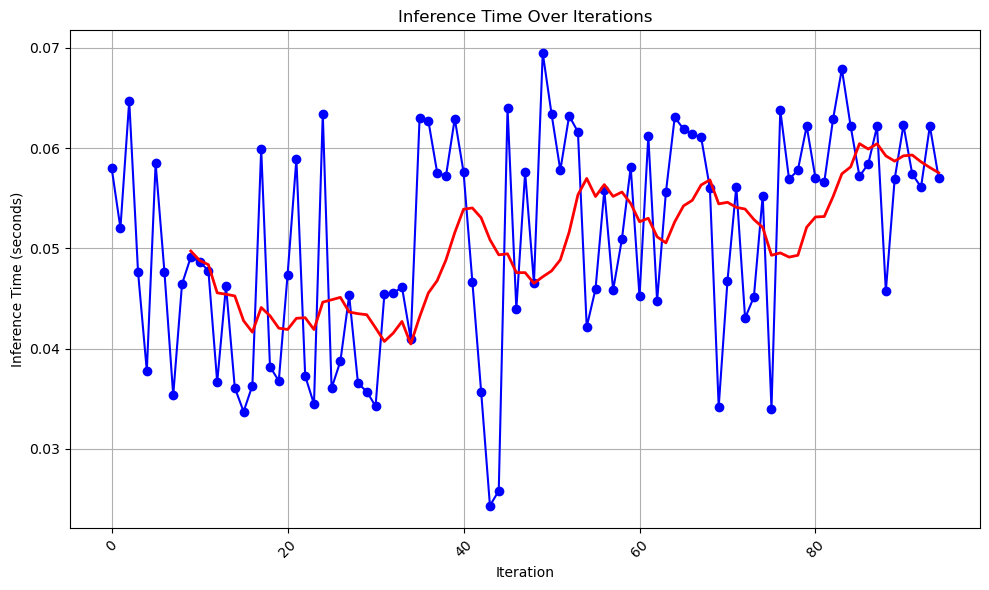

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(data.index, data[0].astype(float), marker='o', linestyle='-', color='b')
plt.plot(data.index, data['rolling_mean'], color='r', linewidth=2, label='Rolling Mean (100 iterations)')
plt.title('Inference Time Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Inference Time (seconds)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

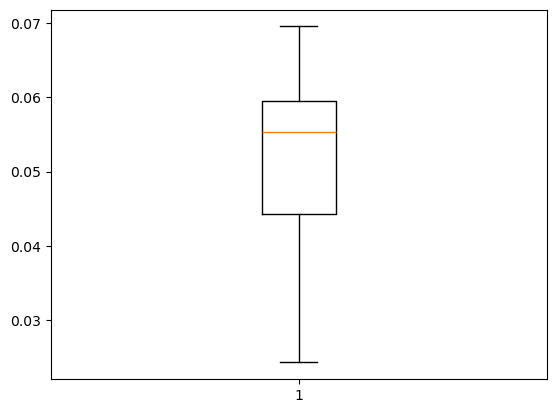

In [13]:
plt.boxplot(data[0].astype(float))
plt.show()

In [14]:
data[0].astype(float).describe()

count    95.000000
mean      0.050854
std       0.010666
min       0.024325
25%       0.044343
50%       0.055274
75%       0.059424
max       0.069498
Name: 0, dtype: float64